In [158]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

In [159]:
class SinusoidalPositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()

        self.d_model = d_model

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()

        div_term = torch.exp( torch.arange(0, d_model, 2).float() / d_model * (-math.log(10000.0)))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
      # x: (B, S, d_model)

      seq_len = x.size(1)

      # (B, S, d_model)
      return x + self.pe[:, :seq_len, :]

In [160]:
pos_enc = SinusoidalPositionalEncoding(d_model=512, max_len=100)
pe = pos_enc.pe.squeeze(0).detach().cpu()

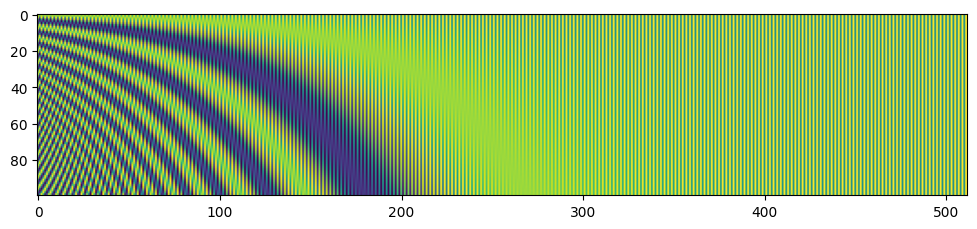

In [161]:
plt.figure(figsize=(12, 10))
plt.imshow(pe)
plt.show()

In [162]:
class RotatoryEmbeddings(nn.Module):
  def __init__(self, dim, max_seq_len = 2048, base = 10000):
    super().__init__()
    self.dim = dim
    self.max_seq_len = max_seq_len
    self.base = base

    inv_freq = 1. / (self.base ** (torch.arange(0, dim, 2).float() / self.dim))

    position = torch.arange(max_seq_len).float()
    freqs = torch.outer(position, inv_freq)

    self.register_buffer('cos_cached', freqs.cos())
    self.register_buffer('sin_cached', freqs.sin())

  def forward(self, q, k):

    seq_len = q.shape[2]
    cos = self.cos_cached[:seq_len].unsqueeze(0).unsqueeze(0)
    sin = self.sin_cached[:seq_len].unsqueeze(0).unsqueeze(0)

    q = self.rotate(q, cos, sin)
    k = self.rotate(k, cos, sin)
    return q, k

  def rotate(self, x, cos, sin):

    x1 = x[..., ::2]
    x2 = x[..., 1::2]

    rotated_x1 = (x1 * cos - x2 * sin)
    rotated_x2 = (x1 * sin + x2 * cos)
    x_rotated = torch.stack([rotated_x1,rotated_x2],dim=-1)

    return x_rotated.flatten(-2)

In [163]:
rope = RotatoryEmbeddings(dim=512)
q = torch.rand(1,1, 100, 512)
out = rope(q, q)

In [164]:
enc_q = out[0].squeeze(0).squeeze(0).detach().cpu().numpy()
enc_k = out[1].squeeze(0).squeeze(0).detach().cpu().numpy()

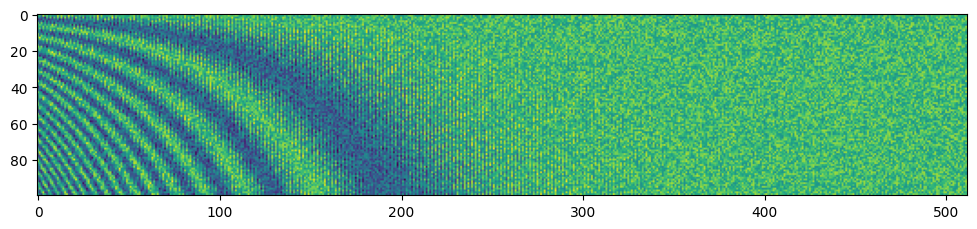

In [165]:
plt.figure(figsize=(12, 10))
plt.imshow(enc_q)
plt.show()

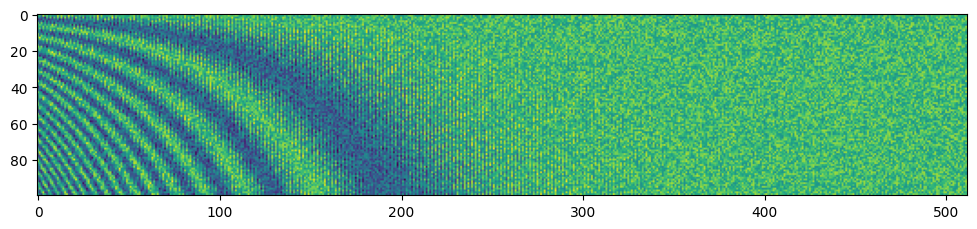

In [166]:
plt.figure(figsize=(12, 10))
plt.imshow(enc_k)
plt.show()